In [2]:
#imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("electricity_in_the_world.csv", delimiter=",", skiprows=4)
meta = pd.read_csv("Metadata_Country.csv", delimiter= ",")
df.tail()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
260,Kosovo,XKX,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,79.2,62.0,72.8,73.9,74.9,76.0,83.6,86.3,NaN,NaN
262,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,84.4,84.7,85.0,90.0,89.3,86.5,87.7,90.2,NaN,NaN
263,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.3,40.2,43.0,44.6,46.7,47.8,51.1,53.6,NaN,NaN
264,Zimbabwe,ZWE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,44.0,45.4,46.7,52.7,49.0,50.1,62.0,62.0,NaN,NaN


In [4]:
meta.head()


,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [5]:
df.info()
meta.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [6]:
year_cols = [c for c in df.columns if c.strip().isdigit()]
year_cols

['1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025']

In [7]:
long_df = df.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Electricity_Access"
)
long_df.head()

,Country Name,Country Code,Year,Electricity_Access
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,NaN
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,NaN
4,Angola,AGO,1960,NaN


In [8]:
#reshape wide to long
long_df = df.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Electricity_Access"
)
long_df.head()

,Country Name,Country Code,Year,Electricity_Access
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,NaN
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,NaN
4,Angola,AGO,1960,NaN


In [9]:
#merge in Region/IncomeGroup
long_df = long_df.merge(
    meta[["Country Code", "Region", "IncomeGroup"]],
    on="Country Code",
    how="left"
)
long_df.head()

,Country Name,Country Code,Year,Electricity_Access,Region,IncomeGroup
0,Aruba,ABW,1960,NaN,Latin America & Caribbean,High income
1,Africa Eastern and Southern,AFE,1960,NaN,NaN,NaN
2,Afghanistan,AFG,1960,NaN,Middle East & North Africa,Low income
3,Africa Western and Central,AFW,1960,NaN,NaN,NaN
4,Angola,AGO,1960,NaN,Sub-Saharan Africa,Lower middle income


In [10]:
# Keep only real countries, dropping World Bank's regional/aggregate rows
world_df = long_df[long_df["Region"].notna()].copy()
world_df.shape

(14322, 6)

In [11]:
# Check how many countries made it into the cleaned dataset
world_df["Country Name"].nunique()

217

In [12]:
# Convert Year from text to a proper integer so it can be used numerically
world_df["Year"] = world_df["Year"].astype(int)

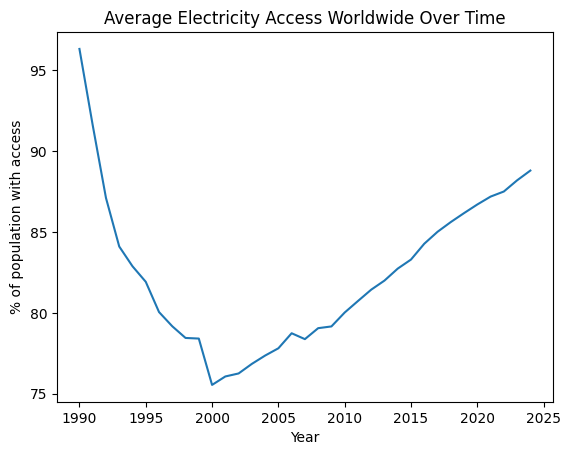

In [13]:
# Visualize how average electricity access has changed globally over time
yearly_avg = world_df.groupby("Year")["Electricity_Access"].mean()
yearly_avg.plot(title="Average Electricity Access Worldwide Over Time")
plt.ylabel("% of population with access")
plt.show()

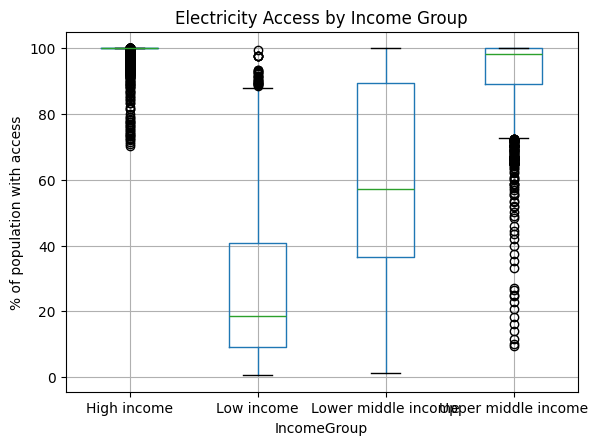

In [14]:
# Visualize how electricity access differs across income groups
world_df.boxplot(column="Electricity_Access", by="IncomeGroup")
plt.title("Electricity Access by Income Group")
plt.suptitle("")
plt.ylabel("% of population with access")
plt.show()

In [15]:
# Drop rows where the target value itself is missing, since we can't train on those
world_df = world_df.dropna(subset=["Electricity_Access"])

In [16]:
# Convert IncomeGroup to numbers, preserving its natural low-to-high order
income_order = {
    "Low income": 0,
    "Lower middle income": 1,
    "Upper middle income": 2,
    "High income": 3
}
world_df["IncomeGroup_num"] = world_df["IncomeGroup"].map(income_order)

In [17]:
# Convert Region to numbers using one-hot encoding, since regions have no natural order
region_dummies = pd.get_dummies(world_df["Region"], prefix="Region", drop_first=True)
world_df = pd.concat([world_df, region_dummies], axis=1)
world_df.head()

,Country Name,Country Code,Year,Electricity_Access,Region,IncomeGroup,IncomeGroup_num,Region_Europe & Central Asia,Region_Latin America & Caribbean,Region_Middle East & North Africa,Region_North America,Region_South Asia,Region_Sub-Saharan Africa
7950,Aruba,ABW,1990,100.0000,Latin America & Caribbean,High income,3,False,True,False,False,False,False
7955,Albania,ALB,1990,100.0000,Europe & Central Asia,Upper middle income,2,True,False,False,False,False,False
7956,Andorra,AND,1990,100.0000,Europe & Central Asia,High income,3,True,False,False,False,False,False
7958,United Arab Emirates,ARE,1990,100.0000,Middle East & North Africa,High income,3,False,False,True,False,False,False
7959,Argentina,ARG,1990,92.1548,Latin America & Caribbean,Upper middle income,2,False,True,False,False,False,False


In [18]:
# Build the final table containing only the columns the model will actually use
feature_cols = ["Year", "IncomeGroup_num"] + list(region_dummies.columns)
model_df = world_df[feature_cols + ["Electricity_Access"]].dropna()
model_df.head()

,Year,IncomeGroup_num,Region_Europe & Central Asia,Region_Latin America & Caribbean,Region_Middle East & North Africa,Region_North America,Region_South Asia,Region_Sub-Saharan Africa,Electricity_Access
7950,1990,3,False,True,False,False,False,False,100.0000
7955,1990,2,True,False,False,False,False,False,100.0000
7956,1990,3,True,False,False,False,False,False,100.0000
7958,1990,3,False,False,True,False,False,False,100.0000
7959,1990,2,False,True,False,False,False,False,92.1548


In [19]:
# Separate the input features (X) from the value we're trying to predict (y)
X = model_df[feature_cols]
y = model_df["Electricity_Access"]

In [20]:
# Standardize features so Year and Region/Income indicators are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.94465376,  0.94936374, -0.63275082,  1.98657518, -0.34131866,
        -0.12573182, -0.16077205, -0.50823139],
       [-1.94465376, -0.02691383,  1.58040096, -0.50337889, -0.34131866,
        -0.12573182, -0.16077205, -0.50823139],
       [-1.94465376,  0.94936374,  1.58040096, -0.50337889, -0.34131866,
        -0.12573182, -0.16077205, -0.50823139],
       [-1.94465376,  0.94936374, -0.63275082, -0.50337889,  2.92981344,
        -0.12573182, -0.16077205, -0.50823139],
       [-1.94465376, -0.02691383, -0.63275082,  1.98657518, -0.34131866,
        -0.12573182, -0.16077205, -0.50823139]])

In [21]:
# Split data into training and testing sets so we can check performance on unseen data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [31]:
# Train a Stochastic Gradient Descent linear regression model, tracking loss per epoch
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [32]:
# Train a Stochastic Gradient Descent linear regression model, tracking loss per epoch
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42)

train_losses = []
test_losses = []

for epoch in range(100):
    sgd_model.fit(X_train, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_model.predict(X_train)))
    test_losses.append(mean_squared_error(y_test, sgd_model.predict(X_test)))

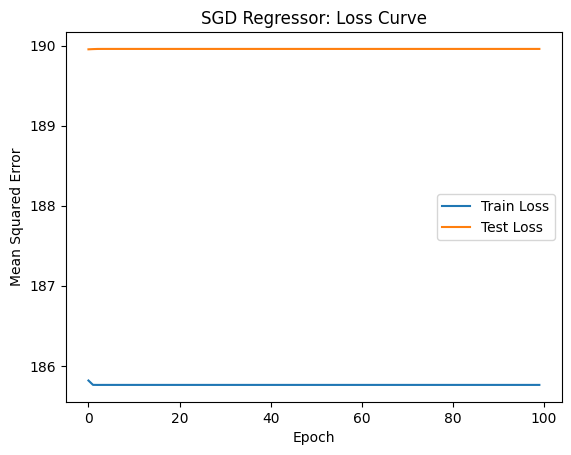

In [23]:
# Plot the loss curve to see how training vs test error changed over epochs
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGD Regressor: Loss Curve")
plt.legend()
plt.show()

In [24]:
# Check final performance of the SGD model
print("SGD Train MSE:", train_losses[-1])
print("SGD Test MSE:", test_losses[-1])

SGD Train MSE: 185.7615462397829
SGD Test MSE: 189.95775907962042


In [25]:
# Import the three other regression algorithms we'll compare against SGD
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [26]:
# Train a standard Linear Regression model and check its error
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_train_mse = mean_squared_error(y_train, lr_model.predict(X_train))
lr_test_mse = mean_squared_error(y_test, lr_model.predict(X_test))

print("Linear Regression Train MSE:", lr_train_mse)
print("Linear Regression Test MSE:", lr_test_mse)

Linear Regression Train MSE: 184.88832172161585
Linear Regression Test MSE: 190.13420775067107


In [27]:
# Train a Random Forest model and check its error
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_train_mse = mean_squared_error(y_train, rf_model.predict(X_train))
rf_test_mse = mean_squared_error(y_test, rf_model.predict(X_test))

print("Random Forest Train MSE:", rf_train_mse)
print("Random Forest Test MSE:", rf_test_mse)

Random Forest Train MSE: 83.0307151514184
Random Forest Test MSE: 144.3803261149213


In [28]:
# Train a Decision Tree model and check its error
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_train_mse = mean_squared_error(y_train, dt_model.predict(X_train))
dt_test_mse = mean_squared_error(y_test, dt_model.predict(X_test))

print("Decision Tree Train MSE:", dt_train_mse)
print("Decision Tree Test MSE:", dt_test_mse)

Decision Tree Train MSE: 82.70345795460187
Decision Tree Test MSE: 152.9740814198275


In [29]:
# Put all four models' results side by side to compare
results = pd.DataFrame({
    "Model": ["SGD", "Linear Regression", "Random Forest", "Decision Tree"],
    "Train MSE": [train_losses[-1], lr_train_mse, rf_train_mse, dt_train_mse],
    "Test MSE": [test_losses[-1], lr_test_mse, rf_test_mse, dt_test_mse]
})
results

,Model,Train MSE,Test MSE
0,SGD,185.761546,189.957759
1,Linear Regression,184.888322,190.134208
2,Random Forest,83.030715,144.380326
3,Decision Tree,82.703458,152.974081


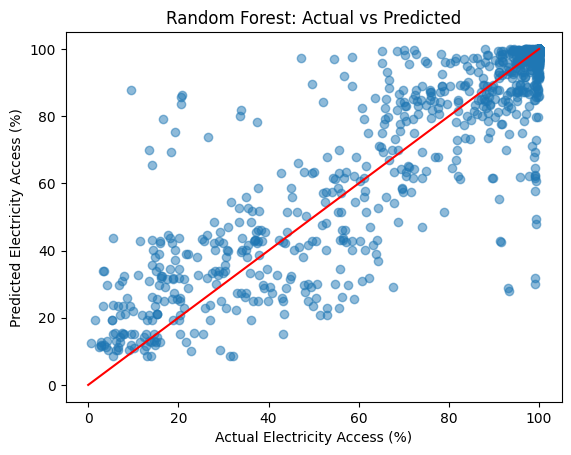

In [30]:
# Scatter plot: actual vs predicted values for the best model (Random Forest)
plt.scatter(y_test, rf_model.predict(X_test), alpha=0.5)
plt.xlabel("Actual Electricity Access (%)")
plt.ylabel("Predicted Electricity Access (%)")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([0, 100], [0, 100], color="red")  # reference line: perfect predictions would sit on this line
plt.show()

In [33]:
# Save the best-performing model (Random Forest) to a file for later use
import joblib

joblib.dump(rf_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']